Code to reproduce analysis of Figure 4 of "Light Levels Reconfigure Species-Specific Instinctive Responses to Threat and Prey" by Reinhard et al.

In [1]:
# LightLevelsReconfigureInstinctiveReponses.yml contains necessary packages

import pickle
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import os
import numpy as np
from pathlib import Path
from scipy.signal import resample

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import KFold

import scipy.io
from scipy import stats
from scipy.spatial.distance import cdist
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import kstest

from datetime import datetime

import seaborn as sb
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection

import dabest

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:01<00:00,  6.95it/s]

Numba compilation complete!


In [2]:
# set path to data
src = Path.cwd()
experiment_data_path = r'C:\Users\katja\OneDrive\POSTDOC\PROJECTS\Pero_Lightlevels\Peromyscus_LightLevels1\manuscript_lightlevel_behavior\VERSION2025\FrontiersZoology\Rebuttal01\to upload'

In [3]:
# load data
experiment_data_file = 'main_data.mat'
experiment_load_path = os.path.join(experiment_data_path,experiment_data_file)
data_raw = scipy.io.loadmat(experiment_load_path)
experiment_data_file2 = 'main_data_autobehv.mat'
experiment_load_path2 = os.path.join(experiment_data_path,experiment_data_file2)
behv_auto = scipy.io.loadmat(experiment_load_path2)
experiment_data_file3 = 'main_data_autobehv_newThr.mat'
experiment_load_path3 = os.path.join(experiment_data_path,experiment_data_file3)
behv_auto_new = scipy.io.loadmat(experiment_load_path3)
experiment_data_file4 = 'main_data_perAnimalInfo.mat'
experiment_load_path4 = os.path.join(experiment_data_path,experiment_data_file4)
per_animal_info = scipy.io.loadmat(experiment_load_path4)
experiment_data_file5 = 'main_data_taken.mat'
experiment_load_path5 = os.path.join(experiment_data_path,experiment_data_file5)
taken_ids = scipy.io.loadmat(experiment_load_path5)
experiment_data_file6 = 'index_helpers.mat'
experiment_load_path6 = os.path.join(experiment_data_path,experiment_data_file6)
index_helpers = scipy.io.loadmat(experiment_load_path6)
data_raw.keys()

dict_keys(['__header__', '__version__', '__globals__', 'ALL_BEH', 'ALL_CORN', 'ALL_SPEED', 'ANIMALID', 'COORDX', 'COORDY', 'FPS', 'IDS', 'PIX2CM', 'SHELTER', 'SIMP_BEH', 'TAKEN', 'conds', 'sorted_by_max'])

In [4]:
# extract necessary variables
IDS = data_raw['IDS'] #experimenter ID
TAKEN = data_raw['TAKEN'] #trials that were included in analysis, 24x29
ANIMALID = data_raw['ANIMALID'] #animal identifier
AUTOnew = behv_auto_new['behv_auto_curr'] #automated behaviour classification
speed = data_raw['ALL_SPEED'] #speed traces
behv = data_raw['ALL_BEH'] #manual classification

In [5]:
# reshape variables and create light and stimulus matrices
base_pattern = [1, 2, 3, 1, 2, 3]
species = np.repeat(base_pattern, 4)
species = np.repeat(species, 29)
speed_r = speed.reshape(-1, 450)
behv_r = behv.reshape(-1,1)
behv_r.squeeze()
#speed_r = speed_r[:,150:]
base_pattern2 = [1, 1, 1, 0, 0, 0]
light = np.repeat(base_pattern2, 4)
light = np.repeat(light, 29)
base_pattern3 = np.repeat([0, 1, 2, 3], 29)  # Each number repeated 29 times
stimulus = np.tile(base_pattern3, 6)
animal = list(range(1, 30)) * 24
animal = np.array(animal)
taken = TAKEN.reshape(-1,1)
taken_r = TAKEN.reshape(-1,1)

In [6]:
# give animals and stimuli different IDs depending on light level
ids = np.argwhere(species==2)
animal[ids] = animal[ids]*100
ids = np.argwhere(species==3)
animal[ids] = animal[ids]*1000
stimulus2 = stimulus.copy()
stimulus2[348:] = stimulus2[348:]+10

# Reshape and average every 5 points for speed traces
speed_rm = np.mean(speed_r.reshape(696, 450//5, 5), axis=2)
print(speed_rm.shape) 

(696, 90)


In [7]:
# decide whether to analyse pre-stimulus or evoked behaviour
doPreStim = 0 #1 if looking at pre-stim speed, 0 if looking at during stimulus

In [8]:
# collect all necessary data
if doPreStim == 1:
    rngtake1 = 0
    rngtake2 = 30
else:
    rngtake1 = 28
    rngtake2 = 62

rows = []
rowsM = []
rowsP = []
taken_rows = []
counter = -1
for ani_idx in range(len(animal)):  # Loop through each animal
    if taken[ani_idx]>0:
        if stimulus[ani_idx]<3: #do not analyse sweeping
            counter = counter + 1
            taken_rows.append(animal[ani_idx])
            for speed_bin in range(rngtake1,rngtake2): # go through speed bins

                lat = np.where(speed_rm[ani_idx, 32:60]>30)[0] #crude escape latency calc
                if lat.size > 0:  
                    lat = lat[0]  
                else:
                    lat = 30
                stop = np.where(speed_rm[ani_idx, 32:60]<5) #crude stop latency calc
                
                rows.append({
                    'behv_type': behv_r[ani_idx][0],     
                    'stim_idx': stimulus[ani_idx],   
                    'animal_id': animal[ani_idx],     
                    'light_id': light[ani_idx],      
                    'species_id': species[ani_idx],   
                    'speed': speed_rm[ani_idx, speed_bin], 
                    'behv_auto_new': AUTOnew[counter][0]
                })
                rowsP.append({
                    'behv_type': behv_r[ani_idx][0],     
                    'stim_idx': stimulus[ani_idx],   
                    'animal_id': animal[ani_idx],    
                    'light_id': light[ani_idx],      
                    'species_id': species[ani_idx],    
                    'speed': speed_rm[ani_idx, speed_bin],  
                    'speed_pre': np.mean(speed_rm[ani_idx, 20:28]),
                    'speed_max': np.max(speed_rm[ani_idx, 32:60]),
                    'max_lat': np.argmax(speed_rm[ani_idx, 30:60]),
                    'speed_mean': np.mean(speed_rm[ani_idx, 32:60]),
                    'stopping': len(stop[0]),
                    'first_lat': lat,
                    'behv_auto_new': AUTOnew[counter][0],
                })
            rowsM.append({
                'behv_type': behv_r[ani_idx][0],       
                'stim_idx': stimulus[ani_idx],    
                'animal_id': animal[ani_idx],    
                'light_id': light[ani_idx],      
                'species_id': species[ani_idx],  
                'speed': np.max(speed_rm[ani_idx, 14:]),  
                'behv_auto_new': AUTOnew[counter][0],
            })

            

# Create the DataFrame
sSC_df = pd.DataFrame(rows)
sSC_df_2 = pd.DataFrame(rowsM)
sSC_df_3 = pd.DataFrame(rowsP)

print(sSC_df.head())
print(f"\nTotal rows: {len(sSC_df)}")
print(f"Columns: {list(sSC_df.columns)}")

   behv_type  stim_idx  animal_id  light_id  species_id      speed  \
0          2         0          1         1           1  11.813522   
1          2         0          1         1           1   9.259570   
2          2         0          1         1           1   6.393666   
3          2         0          1         1           1   2.505162   
4          2         0          1         1           1   2.759818   

   behv_auto_new  
0              0  
1              0  
2              0  
3              0  
4              0  

Total rows: 10064
Columns: ['behv_type', 'stim_idx', 'animal_id', 'light_id', 'species_id', 'speed', 'behv_auto_new']


In [9]:
# fit mixed effect model
if doPreStim == 1:
    formula = "speed ~ 1 + light_id + C(species_id) + behv_auto_new  "
    md = smf.mixedlm(formula, sSC_df_3, groups='animal_id', re_formula="~1 + light_id + species_id + behv_auto_new ")
else:
    formula = "speed ~ 1 + light_id + C(species_id) + C(stim_idx)"
    md = smf.mixedlm(formula, sSC_df_3, groups='animal_id', re_formula="~1 + light_id + species_id ")
mdf = md.fit(method='lbfgs')
print(mdf.summary())

                 Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     speed      
No. Observations:       10064       Method:                 REML       
No. Groups:             67          Scale:                  472.7576   
Min. group size:        34          Log-Likelihood:         -45386.9874
Max. group size:        408         Converged:              Yes        
Mean group size:        150.2                                          
-----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------
Intercept                   12.708    1.221 10.409 0.000  10.316 15.101
C(species_id)[T.2]           6.034    1.220  4.944 0.000   3.642  8.426
C(species_id)[T.3]           7.451    1.277  5.834 0.000   4.948  9.955
C(stim_idx)[T.1]             7.496    0.626 11.967 0.000   6.268  8.723
C(stim_id

C:\Users\katja\AppData\Local\Temp\ipykernel_17028\1837103038.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sb.pointplot(x='Estimate', y='Term', data=fe_df, join=False)


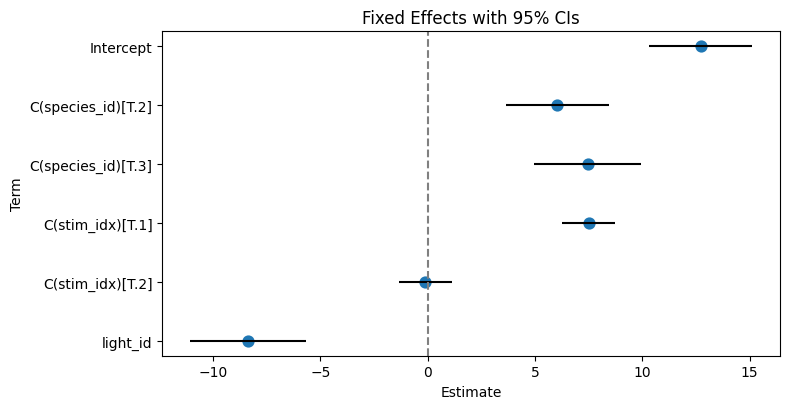

In [10]:
# plot output of the mixed effect model (Fig. 4B)
def extract_and_plot_fixed_effects(mdf,save_path=None):
   
    # Get the fixed effects as a proper DataFrame
    fe_df = pd.DataFrame({
        'Term': mdf.params.index,
        'Estimate': mdf.params.values,
        'CI_lower': mdf.conf_int()[0].values,
        'CI_upper': mdf.conf_int()[1].values
    })
    
    fixed_terms = [x for x in fe_df['Term'] if not any(s in x for s in ['Var', 'Cov'])]
    fe_df = fe_df[fe_df['Term'].isin(fixed_terms)]
    
    fig = plt.figure(figsize=(8, max(4, len(fe_df)*0.7)))
    sb.pointplot(x='Estimate', y='Term', data=fe_df, join=False)
    
    # Error bars
    x = fe_df['Estimate']
    plt.errorbar(x=x,
                 y=np.arange(len(fe_df)),
                 xerr=[x-fe_df['CI_lower'], fe_df['CI_upper']-x],
                 fmt='none', color='black')
    
    plt.axvline(0, linestyle='--', color='gray')
    plt.title("Fixed Effects with 95% CIs")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, format='svg', bbox_inches='tight')
        print(f"Plot saved to {save_path}")
        
    plt.show()

# extract_and_plot_fixed_effects(mdf,save_path='fixed_effects_preSpeedBin5_simple_new.svg')
extract_and_plot_fixed_effects(mdf)

In [11]:
# make simpler behaviour variable (all escape-like behaviours are bundled)
AUTOsimple = AUTOnew.copy()
ij = np.argwhere(AUTOnew==3)
AUTOsimple[ij] = 2
ij = np.argwhere(AUTOnew>3)
AUTOsimple[ij] = 3

2 0 0 [-1] 3


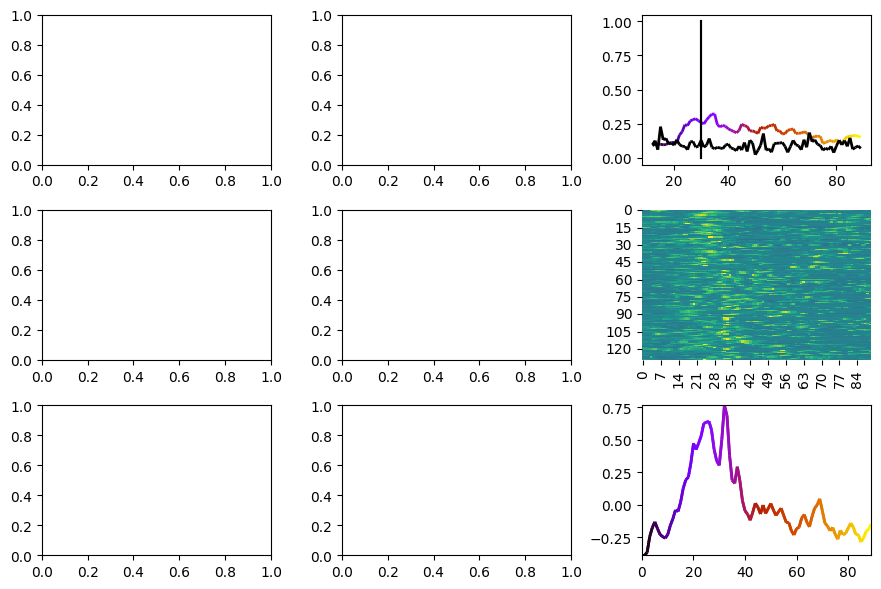

In [12]:
# Predict evoked behaviour from pre-stimulus data (Fig. 4D) - slow due to shuffling
from matplotlib.collections import LineCollection


# ======== select species and bin size ================
species2do = 3 # 1 = Mm, 2 = Pm, 3 = Pp
startbinning = 2 #in seconds
# ========================================================

dorand = 1
supershuffle = 1
growing = 0

plotversion = 0
mod2plot = 3 #usually 3, i.e. just speed, no species or light info
escapealigned = 0

full = 0
stimlist = [-1]


# peranim = 1# if 1 do per animal, otherwise per stimulus type
fig, ax = plt.subplots(3, 3, figsize=(9, 6))

print(startbinning,escapealigned,full,stimlist,mod2plot)

if full == 1:
    speed2take = speed_r
else:
    speed2take = speed_rm
starter = int(speed2take.shape[1]/450*30*startbinning)

if escapealigned == 1:
    speed_rm_n = np.zeros(shape=(speed2take.shape[0], int(speed2take.shape[1]/3*2)))
else:
     speed_rm_n = np.zeros(shape=(speed2take.shape[0], speed2take.shape[1]))
onsets = [];
for s in range(speed2take.shape[0]):
    if species[s] == 1:
        thrsh = 30
    else:
        thrsh = 50
    trace = speed2take[s,:] 
    lat = np.where(trace[int(speed2take.shape[1]/3)+1:int(speed2take.shape[1]/3*2)-2]>thrsh)[0]
    if lat.size > 0:  # Explicitly check array size
        lat = lat[0]  # Adjust for slicing (16:30)
    else:
        lat = np.argmax(trace[int(speed2take.shape[1]/3)+1:int(speed2take.shape[1]/3*2)-2])
    trace = trace - np.mean(trace)
    if np.std(trace) > 0:
        trace = trace / np.std(trace)
    if escapealigned == 1:
        speed_rm_n[s, :] = trace[int(speed2take.shape[1]/3+1+lat-speed2take.shape[1]/3)+1:int(speed2take.shape[1]/3+1+lat+speed2take.shape[1]/3)+1]
    else:
        speed_rm_n[s, :] = trace
    onsets.append(lat)


    
condition1 = (taken.squeeze() > 0)    # Removes single-dimensional entries
condition2 = (stimulus.squeeze() < 3) 
combined_mask = condition1 & condition2
   
coll_array_real = np.zeros((100,100))
coll_array_shuffle = np.zeros((100,100))
for repetitions in range(0,100):
    for dd in range(dorand+1):
        for sp in range(species2do,species2do+1):
            
            
            reg_coefs = []
            mses = []
            r2s = []
            roundsdone = []
        
            all_reg_coefs = []
            all_mses = []
            all_r2s = []
            all_runs = []
        
            coll2plot = []
        
            for binend in range(starter,speed_rm_n.shape[1]): #range(13,31) for bin size 10, range(26,61) for bin size 5
                if growing == 0:
                    bins = list(range(binend-starter,binend)) #same number of bins but specific range
                else:
                    bins = list(range(0,binend)) #increasing number of bins, list(range(10,binend)) for bin size 10, list(range(20,binend)) for bin size 5
            
                
            
                
               
                curr_speed = speed_rm_n[np.ix_(combined_mask, bins)]
                curr_auto = AUTOsimple
                curr_light = light[combined_mask]
                curr_species = species[combined_mask]
                curr_animal = animal[combined_mask]
                curr_stimulus = stimulus[combined_mask]
                curr_stimulus2 = stimulus2[combined_mask]
        
            
                curr_speed_flat = curr_speed.copy()
                curr_animal_flat = curr_animal.copy()
                curr_stimulus_flat = curr_stimulus.copy()
                curr_light_flat = curr_light.copy()
                curr_auto_flat = curr_auto.copy()
                curr_species_flat = curr_species.copy()
                curr_stimulus2_flat = curr_stimulus2.copy()
                ids_plotsecond = curr_species==sp
                ids_second = curr_species_flat==sp
    
                anim_ids_unique = np.unique(curr_stimulus2)
                
                for stim_idx in stimlist:#[0,1,2,3,4,5]:#range(len(anim_ids_unique)): #0 = dim,1=loom,2 = white, 3=dim dark,4=loom dark,5=white dark
        
                    if stimlist[0] == -1:
                        ids_first = np.array(list(range(len(curr_stimulus2_flat))))
                        ids_plotfirst = np.array(list(range(len(curr_stimulus2))))
                    elif stimlist[0] == -2:
                        if stim_idx == -2:
                            ids_first = np.where(np.isin(curr_stimulus2_flat, [0,1,2]))[0]
                            ids_plotfirst = np.where(np.isin(curr_stimulus2_flat, [0,1,2]))[0]
                        else:
                            ids_first = np.where(np.isin(curr_stimulus2, [10,11,12]))[0]
                            ids_plotfirst = np.where(np.isin(curr_stimulus2, [10,11,12]))[0]
                            
                    else:
                        ids_first = curr_stimulus2_flat==anim_ids_unique[stim_idx]
               
                        ids_plotfirst = curr_stimulus2==anim_ids_unique[stim_idx]
            
                    # ids_now = np.where(ids_first & ids_second)[0]
                    if ids_first.dtype == bool:
                        mask = ids_first
                    else:
                        mask = np.zeros_like(ids_second, dtype=bool)
                        mask[np.asarray(ids_first)] = True
                    ids_now = np.where(mask & ids_second)[0]
            
                   
                    # ids_plotnow = np.where(ids_plotfirst & ids_plotsecond)[0]
                    if ids_plotfirst.dtype == bool:
                        mask = ids_plotfirst
                    else:
                        mask = np.zeros_like(ids_plotsecond, dtype=bool)
                        mask[np.asarray(ids_plotfirst)] = True
                    ids_plotnow = np.where(mask & ids_plotsecond)[0]
                    
                    if binend == starter:
                        coll2plot.append(ids_plotnow)
            
                    # if curr_speed_flat.ndim > 1:
                    speed_now = curr_speed_flat[ids_now,:]
                    # else:
                    #     speed_now = curr_speed_flat[ids_now]
                    species_now = curr_species_flat[ids_now]
                    light_now = curr_light_flat[ids_now]
                    auto_now = curr_auto_flat[ids_now]
                    animals_now = curr_animal_flat[ids_now]
        
                    if dd == 1:
                        if supershuffle==1:
                            test = np.random.permutation(speed_now.flatten())
                            speed_now = test.reshape(speed_now.shape[0],speed_now.shape[1])
                        else:
                            speed_now = np.random.permutation(speed_now)
                            
            
                    for mod in range(4):
                        if mod == 0:
                            # X = np.concatenate([speed_nownow.reshape(-1, 1), species_nownow.reshape(-1, 1), light_nownow.reshape(-1, 1)]).T 
                            X = np.hstack([speed_now, species_now.reshape(-1, 1), light_now.reshape(-1, 1)])
                        elif mod ==  1:
                            X = np.hstack([speed_now, species_now.reshape(-1, 1)])
                        elif mod == 2:
                            X = np.hstack([speed_now, light_now.reshape(-1, 1)])
                        elif mod == 3:
                            X = speed_now
                
                        Y = auto_now.reshape(-1,1)
                
                        reg = LinearRegression().fit(X,Y)
                        mse = mean_squared_error(Y, reg.predict(X))
                        r2 = reg.score(X, Y)
                        
                        if mod == 0:
                            reg_all = reg
                            mse_all = mse
                            r2_all = r2
                        elif mod == 1:
                            reg_species = reg
                            mse_species = mse
                            r2_species = r2
                        elif mod == 2:
                            reg_light = reg
                            mse_light = mse
                            r2_light = r2
                        elif mod == 3:
                            reg_speed = reg
                            mse_speed = mse
                            r2_speed = r2
                
                    if r2_all == 0:
                        r2_species_ratio = np.nan
                        r2_light_ratio = np.nan
                        r2_speed_ratio = np.nan
                    else:
                        r2_species_ratio = r2_species# / r2_all
                        r2_light_ratio = r2_light# / r2_all
                        r2_speed_ratio = r2_speed# / r2_all
                    r2s.append([r2_all, r2_species_ratio, r2_light_ratio, r2_speed_ratio])
                    # print(len(r2s))
                    reg_coefs.append(reg_all.coef_)
                    mses.append(mse_all)
                    roundsdone.append(binend)
            # reg_coefs = np.array(reg_coefs)
            mses = np.array(mses)
            r2s = np.array(r2s)
            roundsdone = np.array(roundsdone)
        
            # all_reg_coefs.append(reg_coefs)
            all_mses.append(mses)
            all_r2s.append(r2s)
            all_runs.append(roundsdone)
        
            # all_reg_coefs = np.array(all_reg_coefs)
            all_mses = np.array(all_mses)
            all_r2s = np.array(all_r2s)
            all_runs = np.array(all_runs)
            all_runs = all_runs.flatten()
            all_r2s = all_r2s.reshape(all_r2s.shape[0]*all_r2s.shape[1],all_r2s.shape[2])
            all_mses = all_mses.reshape(all_mses.shape[0]*all_mses.shape[1])
        
            if dd == 0:
                keep_all_r2s = all_r2s
                coll_array_real[repetitions,0: all_r2s[:,3].shape[0]] = all_r2s[:,mod2plot]
            else:
                coll_array_shuffle[repetitions,0: all_r2s[:,3].shape[0]] = all_r2s[:,mod2plot]
            
            if plotversion == 0 and repetitions == 0:
                unique_bins = np.unique(all_runs)
            
                n_bins = len(unique_bins)
                cmap = plt.cm.gnuplot
        
                datnow = all_r2s
                # datnow = all_mses
               
                conds = np.where(all_runs==all_runs[0])[0].shape[0]
                for cc in range(conds):
                    idsct = list(range(cc,all_runs.shape[0],conds))
                    # plt.plot(all_runs[idsct],all_r2s[idsct,mod2plot],c=all_runs[idsct],cmap=cmap)
                    if datnow.ndim >1:
                        y = datnow[idsct,mod2plot]  # Your line data
                    else:
                        y = datnow[idsct]
                    x = all_runs[idsct]  # X-axis values (e.g., time)
            
                    # Create segments for the gradient line
                    points = np.array([x, y]).T.reshape(-1, 1, 2)
                    segments = np.concatenate([points[:-1], points[1:]], axis=1)
                    
                    # Assign colors using a colormap (e.g., gnuplot)
                    cmap = plt.cm.gnuplot
                    norm = plt.Normalize(x.min(), x.max())
                    if dd == 0:
                        lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2*(cc+1))
                    else:
                        lc = LineCollection(segments, colors='black', norm=norm, linewidth=2*(cc+1))
                    lc.set_array(x)  # Color segments based on x-position
                    ax[0, sp-1].add_collection(lc)
                   
                # Add vertical line at x=150 from y=0 to y=max
                ax[0, sp-1].plot([speed2take.shape[1]/3,speed2take.shape[1]/3],[0, 1],color='black',clip_on=False)                         # Ends at top (100%)
           
                
        
                sp2pl = speed_rm_n[combined_mask,:]
                c2p = np.concatenate(coll2plot).tolist()
                sp2pl = sp2pl[c2p,:]
                sorted_auto = np.argsort(curr_auto[c2p].flatten()) 
                sb.heatmap(
                    sp2pl[sorted_auto,:],  # Transpose to align trials on y-axis (optional)
                    ax=ax[1,sp-1],      # Target the correct subplot
                    vmin=-5,           # Minimum value for color scale
                    vmax=5,         # Maximum value for color scale
                    cmap='viridis',   # Color map (e.g., 'viridis', 'plasma', 'inferno')
                    cbar=False,
                )
        
                # ax[2, sp-1].plot(np.mean(sp2pl,axis=0))
                y = np.mean(sp2pl,axis=0)  # Your line data
                x = np.arange(y.shape[0])  # X-axis values (e.g., time)
        
                # Create segments for the gradient line
                points = np.array([x, y]).T.reshape(-1, 1, 2)
                segments = np.concatenate([points[:-1], points[1:]], axis=1)
                
                # Assign colors using a colormap 
                cmap = plt.cm.gnuplot
                norm = plt.Normalize(x.min(), x.max())
                lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
                lc.set_array(x)  # Color segments based on x-position
                
                # Plot
                ax[2, sp-1].add_collection(lc)
                ax[2, sp-1].set_xlim(x.min(), x.max())
                ax[2, sp-1].set_ylim(y.min(), y.max())
    
            std_random = np.std(all_r2s[:,3])
            diffvals = keep_all_r2s-all_r2s
            goodvals = np.where(diffvals[:,3]>2*std_random)
         
    
plt.tight_layout()
plt.show()
# fig.savefig('bins5_bins2s_stimulusAligned_all.svg', format='svg', bbox_inches='tight')

In [14]:
# --> Confidence intervals and standard deviation

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')
import scipy.stats as st

col_p = []
col_CI = []
col_SD = []
for timepoints in range(0, all_r2s[:,3].shape[0] ):
  
    CI = st.t.interval(0.95, len(coll_array_shuffle[:,timepoints])-1, loc=np.mean(coll_array_shuffle[:,timepoints]), scale=st.sem(coll_array_shuffle[:,timepoints]))
    SD = np.std(coll_array_shuffle[:,timepoints])
    col_CI.append(CI)
    col_SD.append(SD)

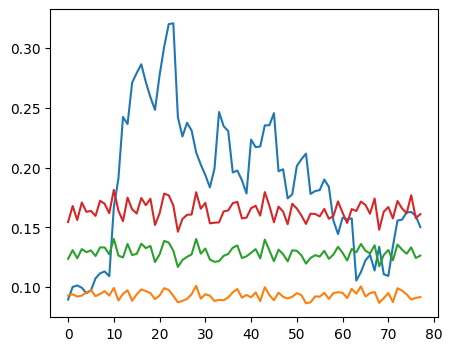

In [15]:
# --> Plot r2 of data vs mean shuffled, 1STD shuffled, 2 STD shuffled
fig = plt.figure(figsize=(5, 4))
R = np.mean(coll_array_real[:,0:all_r2s[:,3].shape[0]],axis=0)
plt.plot(R)
S = np.mean(coll_array_shuffle[:,0:all_r2s[:,3].shape[0]],axis=0)
plt.plot(S)
plt.plot(S+col_SD)
plt.plot(S+np.array(col_SD)*2)
# plt.plot(col_SD)
# fig.savefig('bins5_bins0p5s_stimulusAligned_Mm.svg', format='svg', bbox_inches='tight')

In [16]:
# Permutation test
import dabest
r2a = 18 #18 for 2s, 28 for 0.5s
# Create the first DataFrame
df_real = pd.DataFrame({'DATA': keep_all_r2s[0:r2a,3], 'ID': 'real'})

# Create the second DataFrame  
df_shuffle = pd.DataFrame({'DATA': all_r2s[0:r2a,3], 'ID': 'shuffle'})

# Combine both DataFrames using concat
df = pd.concat([df_real, df_shuffle], ignore_index=True)

# Now use dabest
AA = dabest.load(df, idx=("real", "shuffle"), x="ID", y="DATA")
AA.mean_diff.statistical_tests

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_welch,statistic_welch,pvalue_students_t,statistic_students_t,pvalue_mann_whitney,statistic_mann_whitney
0,real,shuffle,18,18,mean difference,None,-0.069874,95,-0.112256,-0.035899,0.0006,0.001812,3.526754,0.001227,3.526754,0.000419,274.0
